In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import re
from collections import defaultdict

BASE_DIR = "/content/drive/MyDrive/Transfer"

#관심 주제 "여성 참정권"과 "금주법" 단어 빈도 검색(대략적)
keywords = [
    "suffrage",
    "suffragist",
    "suffragette",
    "woman voters",
    "women voters",
    "votes for women",
    "prohibition",
    "temperance"
]

total_counts = defaultdict(int)
file_counts = defaultdict(int)

for year in ["1918", "1919", "1920"]:

    year_path = os.path.join(BASE_DIR, year)

    for filename in os.listdir(year_path):

        if not filename.endswith(".txt"):
            continue

        filepath = os.path.join(year_path, filename)

        try:
            with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read().lower()

            for keyword in keywords:

                count = len(re.findall(re.escape(keyword.lower()), text))

                if count > 0:
                    total_counts[keyword] += count
                    file_counts[keyword] += 1

        except Exception as e:
            print(f"Error: {filename} -> {e}")

print("=" * 50)
print("TOTAL OCCURRENCES")
print("=" * 50)

for keyword in keywords:
    print(f"{keyword:15s} : {total_counts[keyword]}")

print("\n")

print("=" * 50)
print("FILES CONTAINING KEYWORD")
print("=" * 50)

for keyword in keywords:
    print(f"{keyword:15s} : {file_counts[keyword]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TOTAL OCCURRENCES
suffrage        : 5749
suffragist      : 600
suffragette     : 76
woman voters    : 289
women voters    : 90
votes for women : 43
prohibition     : 6802
temperance      : 634


FILES CONTAINING KEYWORD
suffrage        : 880
suffragist      : 244
suffragette     : 53
woman voters    : 167
women voters    : 68
votes for women : 38
prohibition     : 1003
temperance      : 357


In [3]:

BASE_DIR = "/content/drive/MyDrive/Transfer"

co_occurrence_files = []

for year in ["1918", "1919", "1920"]:

    year_path = os.path.join(BASE_DIR, year)

    for filename in os.listdir(year_path):

        if not filename.endswith(".txt"):
            continue

        filepath = os.path.join(year_path, filename)

        try:
            with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read().lower()

            if "suffrage" in text and "prohibition" in text:
                co_occurrence_files.append(filepath)

        except Exception as e:
            print(f"Error: {filename} -> {e}")

print(f"\n동시 등장 파일 수: {len(co_occurrence_files)}")

print("\n예시 파일 20개:")
for f in co_occurrence_files[:20]:
    print(f)

print("\n" + "="*80)
print("SUFFRAGE 주변 문맥 예시")
print("="*80)

for filepath in co_occurrence_files[:5]:

    print("\nFILE:", os.path.basename(filepath))
    print("-"*80)

    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    matches = re.finditer("suffrage", text.lower())

    for i, match in enumerate(matches):

        start = max(0, match.start()-150)
        end = min(len(text), match.end()+150)

        print(text[start:end])
        print("\n" + "-"*40 + "\n")

        if i >= 2:  # 파일당 최대 3개만 출력
            break


동시 등장 파일 수: 823

예시 파일 20개:
/content/drive/MyDrive/Transfer/1918/1918-08-24.txt
/content/drive/MyDrive/Transfer/1918/1918-02-22.txt
/content/drive/MyDrive/Transfer/1918/1918-10-25.txt
/content/drive/MyDrive/Transfer/1918/1918-01-27.txt
/content/drive/MyDrive/Transfer/1918/1918-03-03.txt
/content/drive/MyDrive/Transfer/1918/1918-06-26.txt
/content/drive/MyDrive/Transfer/1918/1918-09-11.txt
/content/drive/MyDrive/Transfer/1918/1918-02-21.txt
/content/drive/MyDrive/Transfer/1918/1918-10-16.txt
/content/drive/MyDrive/Transfer/1918/1918-02-03.txt
/content/drive/MyDrive/Transfer/1918/1918-05-29.txt
/content/drive/MyDrive/Transfer/1918/1918-05-05.txt
/content/drive/MyDrive/Transfer/1918/1918-03-12.txt
/content/drive/MyDrive/Transfer/1918/1918-07-21.txt
/content/drive/MyDrive/Transfer/1918/1918-03-07.txt
/content/drive/MyDrive/Transfer/1918/1918-04-14.txt
/content/drive/MyDrive/Transfer/1918/1918-01-06.txt
/content/drive/MyDrive/Transfer/1918/1918-05-31.txt
/content/drive/MyDrive/Transfer/191

In [4]:
#suffrage 앞뒤 500자 이내의 금주법/여성 참정권 관련 언급 찾기
target = "suffrage"

related_terms = [
    "prohibition",
    "temperance",
    "woman voters",
    "women voters"
]

results = []

for year in ["1918", "1919", "1920"]:

    year_path = os.path.join(BASE_DIR, year)

    for filename in os.listdir(year_path):

        if not filename.endswith(".txt"):
            continue

        filepath = os.path.join(year_path, filename)

        try:
            with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()

            text_lower = text.lower()

            for match in re.finditer(target, text_lower):

                start = max(0, match.start() - 200)
                end = min(len(text), match.end() + 200)

                window = text_lower[start:end]

                found_terms = [
                    term
                    for term in related_terms
                    if term in window
                ]

                if found_terms:

                    snippet_start = max(0, match.start() - 150)
                    snippet_end = min(len(text), match.end() + 150)

                    snippet = text[snippet_start:snippet_end]

                    results.append({
                        "file": filename,
                        "terms": found_terms,
                        "snippet": snippet
                    })

        except Exception as e:
            print(f"Error: {filename} -> {e}")

print(f"\n총 발견 수: {len(results)}")

for r in results[:50]:   # 처음 50개만 출력

    print("\n" + "="*80)
    print("FILE:", r["file"])
    print("FOUND:", ", ".join(r["terms"]))
    print("-"*80)
    print(r["snippet"])


총 발견 수: 246

FILE: 1918-02-03.txt
FOUND: prohibition
--------------------------------------------------------------------------------
titutional amend
ments are something the fashion just
now; but however the individual voter
may register himself with respect to
prohibition or woman suffrage. he can
conscientiously mark a cross in favor
of the proposed resolution granting the
District representation in Congress
?with no other thought than

FILE: 1918-03-07.txt
FOUND: prohibition
--------------------------------------------------------------------------------
 Coombs, secretary, and Dr. Eg
bert Clark, treasurer.
NEW NATIONAL PARTY
ADOPTS LEADING PLANKS
i CHICAGO, March 7.?Nation-wide
r rohibition and woman suffrage will
I be the leading planks in the platform
of the new national party, which re
I sumed sessions of its first national con
vention here today, augme

FILE: 1918-03-07.txt
FOUND: prohibition
--------------------------------------------------------------------------------
nt 

In [5]:
#참정권+금주법 언급과 인과 표현이 동시에 나타난 글 찾기
suffrage_terms = [
    "suffrage",
    "woman voters",
    "women voters",
    "votes for women"
]

prohibition_terms = [
    "prohibition",
    "temperance"
]

causal_terms = [
    "support",
    "supports",
    "supported",
    "oppose",
    "opposes",
    "opposed",
    "aid",
    "aids",
    "help",
    "helps",
    "strengthen",
    "strengthens",
    "favor",
    "favors",
    "promote",
    "promotes",
    "ensure",
    "secure"
]

results = []

for year in ["1918", "1919", "1920"]:

    year_path = os.path.join(BASE_DIR, year)

    for filename in os.listdir(year_path):

        if not filename.endswith(".txt"):
            continue

        filepath = os.path.join(year_path, filename)

        with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()

        text_lower = text.lower()

        for term in suffrage_terms:

            for match in re.finditer(re.escape(term), text_lower):

                start = max(0, match.start() - 100)
                end = min(len(text), match.end() + 100)

                window = text_lower[start:end]

                has_prohibition = any(
                    p in window for p in prohibition_terms
                )

                has_causal = any(
                    c in window for c in causal_terms
                )

                if has_prohibition and has_causal:

                    snippet = text[start:end]

                    results.append({
                        "file": filename,
                        "snippet": snippet
                    })

print(f"\n발견된 후보 수: {len(results)}")

for i, r in enumerate(results[:50]):

    print("\n" + "="*80)
    print(f"[{i+1}] {r['file']}")
    print("-"*80)
    print(r["snippet"])


발견된 후보 수: 25

[1] 1918-02-03.txt
--------------------------------------------------------------------------------
ust
now; but however the individual voter
may register himself with respect to
prohibition or woman suffrage. he can
conscientiously mark a cross in favor
of the proposed resolution granting the
District repr

[2] 1918-01-06.txt
--------------------------------------------------------------------------------
e that clear when,
answering the States Rights objec
tion for Prohibition, he answered
it for woman suffrage.
"Are you afraid to trust your
States?" asks Mr. Webb.
A Sovereign Right
"There is no question of S

[3] 1918-10-02.txt
--------------------------------------------------------------------------------
nts
cents
cents
cents
cents
cents
cents
cents
cents
cents
cents
cents
ccnts
cents
cents
cents
cents
SUFFRAGE PLANK REJECTED.
i
New Jersey Democrats Favor War
Prohibition.
TRKXTOK, N. J., October 2.?An at
temp

[4] 1918-10-02.txt
------------------------------------

In [6]:
suffrage_terms = [
    "suffrage",
    "woman voters",
    "women voters",
    "votes for women"
]

related_terms = [
    "prohibition",
    "temperance",
    "saloon",
    "liquor"
]

results = []

for year in ["1918", "1919", "1920"]:

    year_path = os.path.join(BASE_DIR, year)

    for filename in os.listdir(year_path):

        if not filename.endswith(".txt"):
            continue

        filepath = os.path.join(year_path, filename)

        try:
            with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()

            text_lower = text.lower()

            for s_term in suffrage_terms:

                for match in re.finditer(re.escape(s_term), text_lower):

                    start = max(0, match.start() - 300)
                    end = min(len(text), match.end() + 300)

                    window = text_lower[start:end]

                    found_related = [
                        term for term in related_terms
                        if term in window
                    ]

                    if found_related:

                        snippet = text[start:end]

                        results.append(
                            f"""
FILE: {filename}
SUFFRAGE_TERM: {s_term}
RELATED: {', '.join(found_related)}

{snippet}

{'='*100}
"""
                        )

        except Exception as e:
            print(f"Error: {filename} -> {e}")

# 결과 저장
with open("edge_candidates.txt", "w", encoding="utf-8") as f:
    f.writelines(results)

print(f"총 후보 수: {len(results)}")
print("edge_candidates.txt 저장 완료")

총 후보 수: 275
edge_candidates.txt 저장 완료


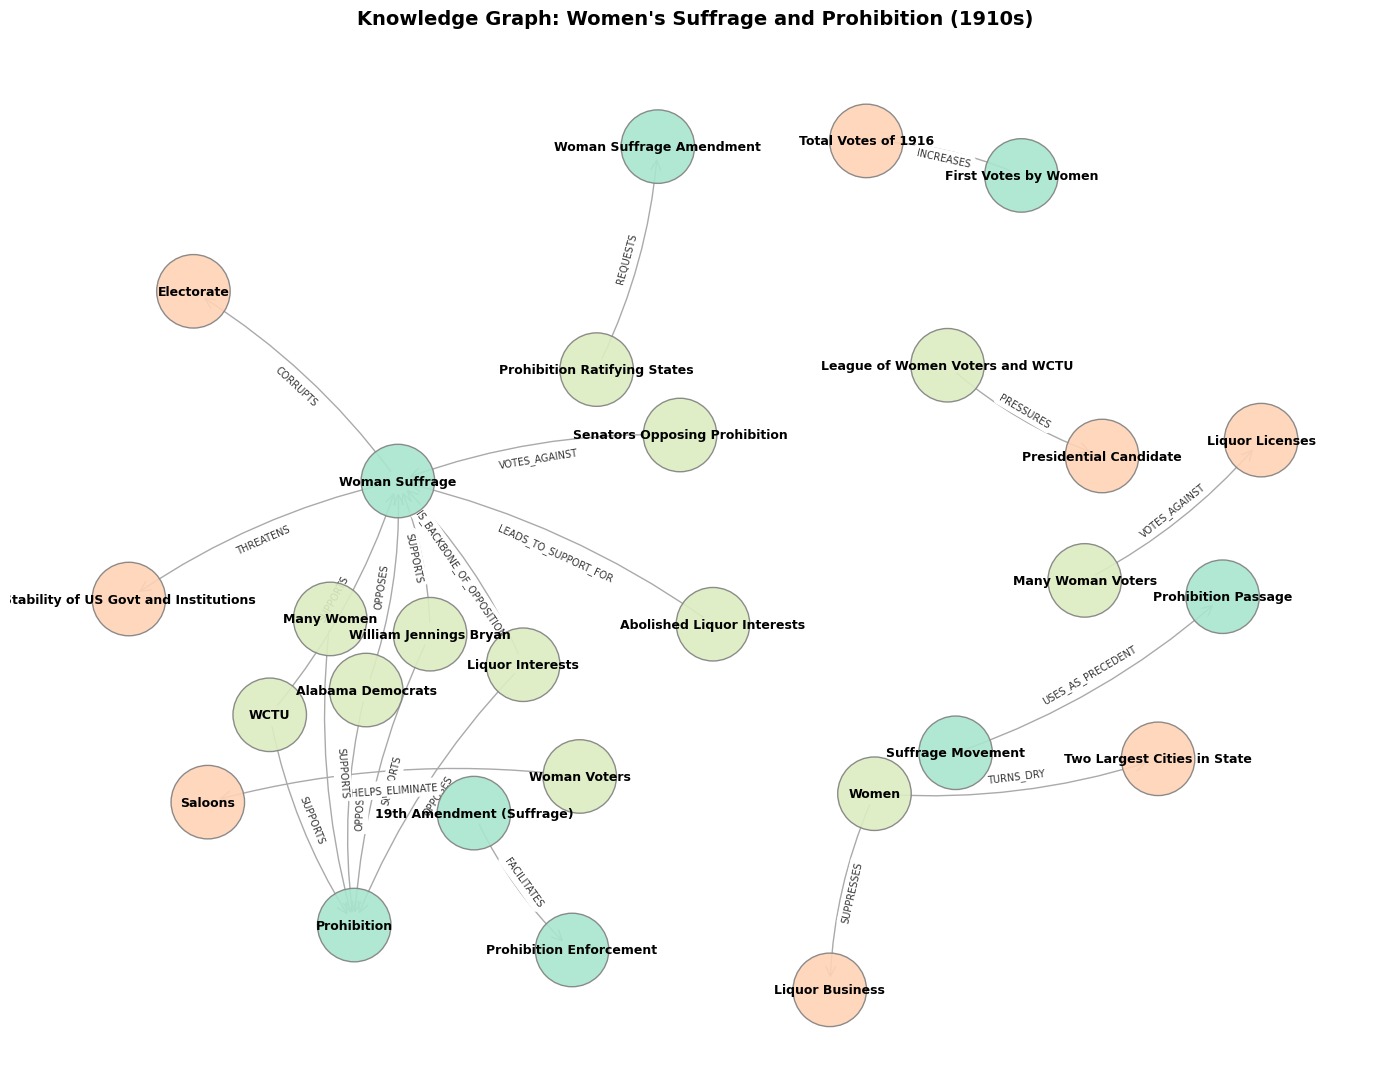

In [4]:
import os
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# 1. 파일 경로 설정
nodes_path = "/content/node.csv"
edges_path = "/content/edges.csv"

# 파일 존재 여부 확인
if not os.path.exists(nodes_path) or not os.path.exists(edges_path):
    raise FileNotFoundError(
        "nodes.csv 또는 edges.csv 파일이 없습니다. 경로를 확인해주세요!"
    )

# 2. CSV 데이터 로드
nodes_df = pd.read_csv(nodes_path)
edges_df = pd.read_csv(edges_path)

# 3. NetworkX 방향성 그래프(DiGraph) 생성
G = nx.DiGraph()

# 노드 추가 (속성으로 node_type과 정식 명칭 label 부여)
for _, row in nodes_df.iterrows():
    G.add_node(row["id"], label=row["label"], type=row["node_type"])

# 엣지 추가 (속성으로 relation_type 부여)
for _, row in edges_df.iterrows():
    G.add_edge(row["source_id"], row["target_id"], relation=row["relation_type"])

# 4. 시각화 설정
plt.figure(figsize=(14, 11))

# 노드 레이아웃 설정 (k값으로 노드 간의 거리를 조절)
pos = nx.spring_layout(G, k=0.6, seed=42)

# 노드 타입별 색상 매핑 (Event: 민트, Subject: 하늘색, Target: 연주황)
color_map = {"Event": "#a8e6cf", "Subject": "#dcedc1", "Target": "#ffd3b6"}
node_colors = [color_map.get(G.nodes[node]["type"], "#e0e0e0") for node in G.nodes]

# 노드 그리기
nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, node_size=2800, alpha=0.9, edgecolors="gray"
)

# 노드 라벨 표시 ('label' 속성 사용)
node_labels = nx.get_node_attributes(G, "label")
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9, font_weight="bold")

# 화살표(에지) 그리기
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=G.edges(),
    edge_color="#aaaaaa",
    arrowsize=18,
    arrowstyle="->",
    connectionstyle="arc3,rad=0.1",
)

# 에지 라벨(관계 종류) 표시
edge_labels = nx.get_edge_attributes(G, "relation")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, alpha=0.8)

# 5. 그래프 출력 및 저장
plt.title(
    "Knowledge Graph: Women's Suffrage and Prohibition (1910s)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.axis("off")
plt.tight_layout()

# 이미지 저장 코드
#plt.savefig("knowledge_graph_output.png", dpi=300)

plt.show()

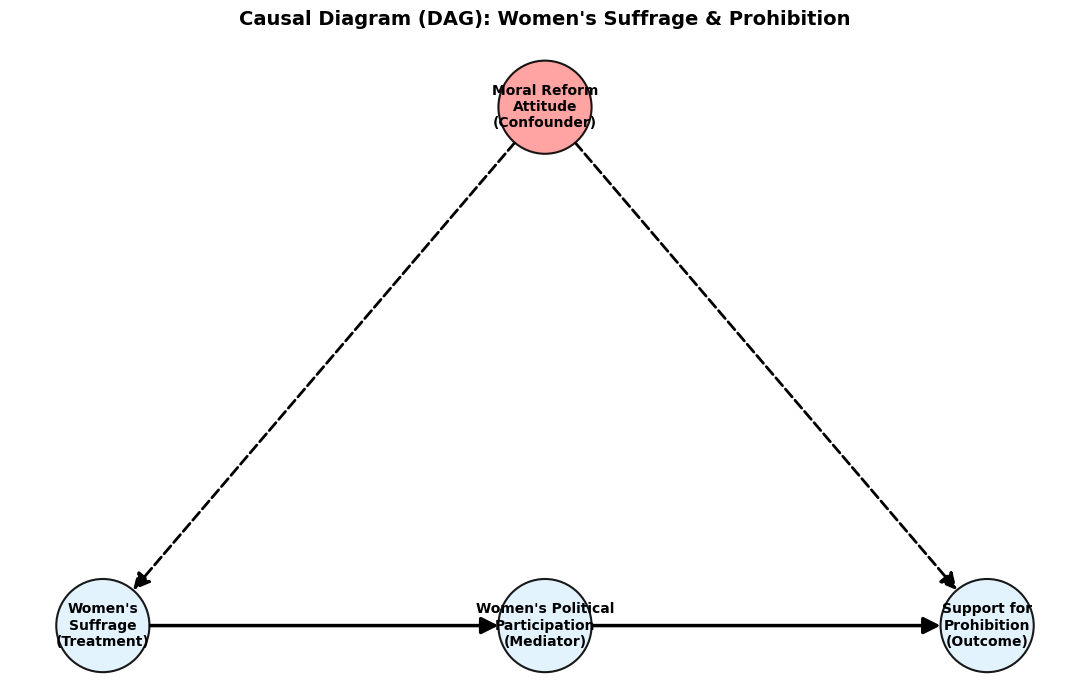

<Figure size 640x480 with 0 Axes>

In [14]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. 방향성 그래프(DiGraph) 생성
dag = nx.DiGraph()

# 2. 노드 정의
nodes = {
    "MRA": "Moral Reform\nAttitude\n(Confounder)",
    "WS": "Women's\nSuffrage\n(Treatment)",
    "WPP": "Women's Political\nParticipation\n(Mediator)",
    "SP": "Support for\nProhibition\n(Outcome)",
}

for key, label in nodes.items():
    dag.add_node(key, label=label)

# 3. 인과관계 화살표(Edge) 정의
dag.add_edge("MRA", "WS", type="confounder")
dag.add_edge("MRA", "SP", type="confounder")
dag.add_edge("WS", "WPP", type="causal")
dag.add_edge("WPP", "SP", type="causal")

# 4. 수동 위치 지정
pos = {
    "MRA": (1.5, 2.0),  # 상단 중앙
    "WS": (0.0, 1.0),   # 좌측
    "WPP": (1.5, 1.0),  # 중앙
    "SP": (3.0, 1.0),   # 우측
}

plt.figure(figsize=(11, 7))

# 5. 노드 컬러 설정
node_colors = {
    "MRA": "#ff9999",
    "WS": "#e0f2fe",
    "WPP": "#e0f2fe",
    "SP": "#e0f2fe",
}
colors = [node_colors[node] for node in dag.nodes]

# 노드 그리기
nx.draw_networkx_nodes(
    dag, pos, node_color=colors, node_size=4500, edgecolors="black", linewidths=1.5, alpha=0.9
)

# 노드 라벨 그리기
node_labels = nx.get_node_attributes(dag, "label")
nx.draw_networkx_labels(dag, pos, labels=node_labels, font_size=10, font_weight="bold")

# 6. 화살표(에지) 그리기
causal_edges = [(u, v) for u, v, d in dag.edges(data=True) if d["type"] == "causal"]
confounder_edges = [(u, v) for u, v, d in dag.edges(data=True) if d["type"] == "confounder"]

# 주 인과 경로
nx.draw_networkx_edges(
    dag,
    pos,
    edgelist=causal_edges,
    edge_color="#000000",
    width=2.5,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=25,
    node_size=4500,
    connectionstyle="arc3,rad=0.0"
)

# 교란 경로 (검은색 점선 + 명확한 화살표)
nx.draw_networkx_edges(
    dag,
    pos,
    edgelist=confounder_edges,
    edge_color="#000000",
    width=2.0,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=25,
    node_size=4500,
    style="dashed",
    connectionstyle="arc3,rad=0.0"
)

# 7. 출력 설정
plt.title("Causal Diagram (DAG): Women's Suffrage & Prohibition", fontsize=14, fontweight="bold", pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()
#plt.savefig("causal_diagram_moral.png", dpi=300)